<a href="https://colab.research.google.com/github/Cairo-Henrique/BQC-Quantum-Tech/blob/main/Bloco_3/QInvest_Exerc%C3%ADcio_ML_Cl%C3%A1ssico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# QInvest — Exercício de Machine Learning Clássico

Este notebook apresenta um exercício prático de **Machine Learning Clássico** aplicado a problemas financeiros, com foco em modelagem, treinamento e avaliação de modelos de classificação.

O objetivo é construir, de forma progressiva, um pipeline completo de Machine Learning, incluindo:

- Geração de dados simulados com interpretação financeira
- Separação em treino e teste
- Construção de modelos de rede neural
- Treinamento com PyTorch
- Avaliação com métricas relevantes (F1-score, matriz de confusão)
- Comparação entre diferentes arquiteturas e funções de ativação

---

## Contexto: Machine Learning em Finanças

Machine Learning é amplamente utilizado no setor financeiro para:

- Avaliação de risco de crédito
- Detecção de fraude
- Otimização de portfólio
- Previsão de inadimplência
- Score de clientes

Neste notebook, será explorado um exemplo clássico:

**Previsão de risco de inadimplência** — determinar se um cliente possui maior probabilidade de não pagar uma dívida com base em variáveis financeiras.

---

## Estrutura do Notebook

O notebook está organizado nas seguintes etapas:

1. Geração dos dados simulados
2. Definição do modelo de rede neural
3. Treinamento do modelo
4. Avaliação com métricas
5. Experimentos com diferentes arquiteturas

---

## Bibliotecas Utilizadas

- NumPy
- PyTorch
- Scikit-learn
- Matplotlib (quando necessário)

# Aula 3

## F1 — Risco de Inadimplência (Classificação Binária)

### 🎯 Objetivo
Prever se um cliente terá risco de inadimplência (0 = não, 1 = sim).

### 📊 O que a função `prep_F1()` faz?

1. Gera 5 variáveis financeiras simuladas:
   - `dti` → dívida / renda
   - `util` → utilização do limite
   - `late` → histórico de atrasos
   - `income` → renda normalizada
   - `savings` → reserva financeira

2. Cria um score de risco usando uma combinação linear dessas variáveis + ruído.

3. Converte o score em classe binária (aprox. 30% dos casos são risco alto).

4. Divide os dados em:
   - treino (80%)
   - teste (20%)

5. Normaliza as features (usando apenas dados de treino).

6. Retorna tensores prontos para usar no PyTorch/QNN.

---

### 🧠 Como usar

```python
Xtr, ytr, Xte, yte = prep_F1()


In [ ]:
import numpy as np
import torch

def prep_F1(n=2000, test_ratio=0.2, seed=0):
    rng = np.random.default_rng(seed)

    # 5 features em [0,1]
    dti = rng.uniform(0, 1, n)             # debt-to-income
    util = rng.uniform(0, 1, n)            # uso do limite
    late = rng.uniform(0, 1, n)            # atrasos (proxy)
    income = rng.uniform(0, 1, n)          # renda (norm)
    savings = rng.uniform(0, 1, n)         # reserva (norm)

    X = np.stack([dti, util, late, income, savings], axis=1).astype(np.float32)

    # Regra simples: risco aumenta com dti/util/late e diminui com savings
    score = 1.6*dti + 1.2*util + 1.0*late - 1.0*savings + 0.2*rng.normal(size=n)
    y = (score > np.quantile(score, 0.7)).astype(np.float32)  # ~30% positivos

    # split
    idx = np.arange(n); rng.shuffle(idx)
    cut = int(n*(1-test_ratio))
    tr, te = idx[:cut], idx[cut:]
    Xtr, Xte, ytr, yte = X[tr], X[te], y[tr], y[te]

    # padroniza (fit no treino)
    mu, sig = Xtr.mean(0, keepdims=True), Xtr.std(0, keepdims=True) + 1e-8
    Xtr = (Xtr - mu)/sig
    Xte = (Xte - mu)/sig

    return (torch.tensor(Xtr), torch.tensor(ytr),
            torch.tensor(Xte), torch.tensor(yte))

In [ ]:
import numpy as np
import torch
import torch.nn as nn

# ==========================================
# 1. GERAÇÃO DOS DADOS (Sua função)
# ==========================================
def prep_F1(n=2000, test_ratio=0.2, seed=0):
    rng = np.random.default_rng(seed)

    # 5 features em [0,1]
    dti = rng.uniform(0, 1, n)             # debt-to-income
    util = rng.uniform(0, 1, n)            # uso do limite
    late = rng.uniform(0, 1, n)            # atrasos (proxy)
    income = rng.uniform(0, 1, n)          # renda (norm)
    savings = rng.uniform(0, 1, n)         # reserva (norm)

    X = np.stack([dti, util, late, income, savings], axis=1).astype(np.float32)

    # Regra simples: risco aumenta com dti/util/late e diminui com savings
    score = 1.6*dti + 1.2*util + 1.0*late - 1.0*savings + 0.2*rng.normal(size=n)
    y = (score > np.quantile(score, 0.7)).astype(np.float32)  # ~30% positivos

    # split
    idx = np.arange(n); rng.shuffle(idx)
    cut = int(n*(1-test_ratio))
    tr, te = idx[:cut], idx[cut:]
    Xtr, Xte, ytr, yte = X[tr], X[te], y[tr], y[te]

    # padroniza (fit no treino)
    mu, sig = Xtr.mean(0, keepdims=True), Xtr.std(0, keepdims=True) + 1e-8
    Xtr = (Xtr - mu)/sig
    Xte = (Xte - mu)/sig

    return (torch.tensor(Xtr), torch.tensor(ytr),
            torch.tensor(Xte), torch.tensor(yte))

# ==========================================
# 2. DEFINIÇÃO DA REDE NEURAL (MLP)
# ==========================================
class RiscoInadimplenciaNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.modelo = nn.Sequential(
            nn.Linear(5, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 1)
        )

    def forward(self, x):
        return self.modelo(x)

# ==========================================
# 3. PREPARAÇÃO PARA O TREINO
# ==========================================
# Carregando os dados
Xtr, ytr, Xte, yte = prep_F1()

# AJUSTE IMPORTANTE: O PyTorch espera que Y tenha formato de coluna [n, 1] e não de linha [n]
ytr = ytr.unsqueeze(1)
yte = yte.unsqueeze(1)

# Instanciando modelo, custo e otimizador
modelo = RiscoInadimplenciaNN()
criterio = nn.BCEWithLogitsLoss()
otimizador = torch.optim.Adam(modelo.parameters(), lr=0.01)

# ==========================================
# 4. LOOP DE TREINAMENTO
# ==========================================
epocas = 150

print("Iniciando o treinamento...\n")
for epoca in range(epocas):
    modelo.train() # Coloca a rede em modo de treino

    # Forward pass: passar os dados de treino pela rede
    predicoes = modelo(Xtr)

    # Calcular o erro (Loss)
    perda = criterio(predicoes, ytr)

    # Backward pass: calcular gradientes e atualizar pesos
    otimizador.zero_grad() # Zera gradientes antigos
    perda.backward()       # Calcula novos gradientes
    otimizador.step()      # Atualiza os pesos

    # Mostrar o progresso a cada 30 épocas
    if (epoca + 1) % 30 == 0:
        modelo.eval() # Coloca a rede em modo de avaliação (desliga dropout/batchnorm se houvesse)
        with torch.no_grad(): # Desliga o cálculo de gradientes para economizar memória/CPU

            # Testa a rede com os dados de teste que ela nunca viu
            pred_teste = modelo(Xte)
            perda_teste = criterio(pred_teste, yte)

            # Calculando a acurácia
            # Como usamos BCEWithLogits, a saída é bruta (logits). Precisamos passar pela Sigmoid
            # para virar probabilidade (0 a 1) e depois arredondar (>= 0.5 vira 1, < 0.5 vira 0)
            probabilidades = torch.sigmoid(pred_teste)
            classes_previstas = (probabilidades >= 0.5).float()

            # Compara previsões com a realidade
            acertos = (classes_previstas == yte).float()
            acuracia = acertos.mean() * 100

            print(f"Época [{epoca+1:3}/{epocas}] | Erro Treino: {perda.item():.4f} | Erro Teste: {perda_teste.item():.4f} | Acurácia: {acuracia.item():.2f}%")

print("\nTreinamento concluído!")

Iniciando o treinamento...

Época [ 30/150] | Erro Treino: 0.2465 | Erro Teste: 0.2447 | Acurácia: 90.75%
Época [ 60/150] | Erro Treino: 0.1802 | Erro Teste: 0.1972 | Acurácia: 91.25%
Época [ 90/150] | Erro Treino: 0.1702 | Erro Teste: 0.1919 | Acurácia: 91.50%
Época [120/150] | Erro Treino: 0.1651 | Erro Teste: 0.1978 | Acurácia: 91.75%
Época [150/150] | Erro Treino: 0.1621 | Erro Teste: 0.2029 | Acurácia: 91.25%

Treinamento concluído!


In [ ]:
from sklearn.metrics import confusion_matrix, f1_score
import numpy as np

# ==========================================
# 5. AVALIAÇÃO FINAL E MÉTRICAS
# ==========================================

# Garante que o modelo está no modo de avaliação
modelo.eval()

with torch.no_grad():
    # Passa os dados de teste pela rede
    logits_teste = modelo(Xte)
    probabilidades = torch.sigmoid(logits_teste)
    previsoes = (probabilidades >= 0.5).float()

# Convertendo de Tensores do PyTorch para Arrays do NumPy (necessário para o scikit-learn)
y_real = yte.numpy().flatten()
y_pred = previsoes.numpy().flatten()
probs = probabilidades.numpy().flatten()

print("\n" + "="*40)
print("RELATÓRIO DE DESEMPENHO NO TESTE")
print("="*40 + "\n")

# --- 1. Matriz de Confusão ---
cm = confusion_matrix(y_real, y_pred)
tn, fp, fn, tp = cm.ravel()

print("📊 MATRIZ DE CONFUSÃO:")
print(f"  Verdadeiros Negativos (VN) - Bom pagador, previsto Bom : {tn}")
print(f"  Falsos Positivos      (FP) - Bom pagador, previsto Mau : {fp}  <-- Custo de oportunidade (perdeu cliente)")
print(f"  Falsos Negativos      (FN) - Mau pagador, previsto Bom : {fn}  <-- Risco real (tomou calote)")
print(f"  Verdadeiros Positivos (VP) - Mau pagador, previsto Mau : {tp}\n")

# --- 2. F1 Score ---
# O F1 é a média harmônica entre Precision e Recall. Excelente para dados desbalanceados (seus ~30% de positivos)
f1 = f1_score(y_real, y_pred)
print("🎯 F1 SCORE:")
print(f"  F1 Score: {f1:.4f}\n")

# --- 3. Exemplos Classificados Incorretamente ---
print("🔍 EXEMPLOS CLASSIFICADOS INCORRETAMENTE (Misclassified):")

# Pega os índices onde a previsão foi diferente do valor real
erros_idx = np.where(y_real != y_pred)[0]

if len(erros_idx) == 0:
    print("  Perfeito! O modelo acertou 100% da base de teste.")
else:
    print(f"  Total de erros no teste: {len(erros_idx)} de {len(y_real)} amostras.\n")
    print("  Mostrando até 5 exemplos de onde o modelo se confundiu:")

    # Mostra apenas os 5 primeiros para não inundar o terminal
    for i in erros_idx[:5]:
        print(f"  -> Exemplo {i}:")
        # Mostrando as features com arredondamento para facilitar a leitura
        print(f"     Features (DTI, Util, Late, Inc, Sav): {Xte[i].numpy().round(2)}")
        print(f"     Realidade: {int(y_real[i])} | Previsão do Modelo: {int(y_pred[i])}")
        print(f"     Certeza da Rede: {probs[i]*100:.1f}% de chance de ser inadimplente\n")


RELATÓRIO DE DESEMPENHO NO TESTE

📊 MATRIZ DE CONFUSÃO:
  Verdadeiros Negativos (VN) - Bom pagador, previsto Bom : 250
  Falsos Positivos      (FP) - Bom pagador, previsto Mau : 14  <-- Custo de oportunidade (perdeu cliente)
  Falsos Negativos      (FN) - Mau pagador, previsto Bom : 21  <-- Risco real (tomou calote)
  Verdadeiros Positivos (VP) - Mau pagador, previsto Mau : 115

🎯 F1 SCORE:
  F1 Score: 0.8679

🔍 EXEMPLOS CLASSIFICADOS INCORRETAMENTE (Misclassified):
  Total de erros no teste: 35 de 400 amostras.

  Mostrando até 5 exemplos de onde o modelo se confundiu:
  -> Exemplo 6:
     Features (DTI, Util, Late, Inc, Sav): [ 1.62 -1.   -1.24 -0.51 -1.46]
     Realidade: 0 | Previsão do Modelo: 1
     Certeza da Rede: 89.6% de chance de ser inadimplente

  -> Exemplo 7:
     Features (DTI, Util, Late, Inc, Sav): [-0.35  1.4  -0.96  0.16 -1.54]
     Realidade: 1 | Previsão do Modelo: 0
     Certeza da Rede: 28.5% de chance de ser inadimplente

  -> Exemplo 9:
     Features (DTI, Ut

In [ ]:
import torch
import torch.nn as nn
from sklearn.metrics import f1_score
import numpy as np

# ==========================================
# 1. REDE NEURAL PARAMETRIZÁVEL
# ==========================================
class RiscoInadimplenciaNN(nn.Module):
    # Agora recebemos a função de ativação como parâmetro
    def __init__(self, funcao_ativacao):
        super().__init__()
        self.modelo = nn.Sequential(
            nn.Linear(5, 16),
            funcao_ativacao(), # Injeta a ativação escolhida (Ex: ReLU, Tanh)
            nn.Linear(16, 8),
            funcao_ativacao(), # Injeta a ativação escolhida
            nn.Linear(8, 1)
        )

    def forward(self, x):
        return self.modelo(x)

# ==========================================
# 2. FUNÇÃO DE TREINAMENTO E AVALIAÇÃO
# ==========================================
def treinar_e_avaliar(Xtr, ytr, Xte, yte, classe_ativacao, classe_otimizador, lr, epocas=150):
    # Garante o formato correto dos alvos [n, 1]
    ytr = ytr.view(-1, 1)
    yte = yte.view(-1, 1)

    # 1. Instancia o modelo com a ativação escolhida
    modelo = RiscoInadimplenciaNN(classe_ativacao)

    # 2. Define critério e otimizador escolhido
    criterio = nn.BCEWithLogitsLoss()
    otimizador = classe_otimizador(modelo.parameters(), lr=lr)

    # 3. Loop de Treino
    modelo.train()
    for _ in range(epocas):
        otimizador.zero_grad()
        predicoes = modelo(Xtr)
        perda = criterio(predicoes, ytr)
        perda.backward()
        otimizador.step()

    # 4. Avaliação no Teste
    modelo.eval()
    with torch.no_grad():
        logits_teste = modelo(Xte)
        probabilidades = torch.sigmoid(logits_teste)
        previsoes = (probabilidades >= 0.5).float()

        y_real = yte.numpy().flatten()
        y_pred = previsoes.numpy().flatten()

        # Calcula métricas
        f1 = f1_score(y_real, y_pred, zero_division=0)
        acuracia = (y_real == y_pred).mean()

    return f1, acuracia

# ==========================================
# 3. CONFIGURANDO E RODANDO OS EXPERIMENTOS
# ==========================================
# Dicionários com os hiperparâmetros que queremos testar
ativacoes_para_testar = {
    'ReLU': nn.ReLU,
    'Tanh': nn.Tanh,
    'Sigmoid': nn.Sigmoid
}

otimizadores_para_testar = {
    'Adam': torch.optim.Adam,
    'SGD': torch.optim.SGD
}

taxas_de_aprendizado = [0.1, 0.01, 0.001]

print(f"{'Ativação':<10} | {'Otimizador':<10} | {'LR':<6} | {'Acurácia':<10} | {'F1 Score':<10}")
print("-" * 60)

melhor_f1 = 0
melhor_config = ""

# Loop aninhado (Grid Search) para testar todas as combinações
for nome_ativ, classe_ativ in ativacoes_para_testar.items():
    for nome_otim, classe_otim in otimizadores_para_testar.items():
        for lr in taxas_de_aprendizado:

            # Chama a função que treina do zero e retorna as métricas
            f1, acc = treinar_e_avaliar(
                Xtr, ytr, Xte, yte,
                classe_ativacao=classe_ativ,
                classe_otimizador=classe_otim,
                lr=lr
            )

            # Imprime a linha de resultado formatada
            print(f"{nome_ativ:<10} | {nome_otim:<10} | {lr:<6} | {acc*100:>7.2f}%   | {f1:.4f}")

            # Guarda a melhor configuração baseada no F1 Score
            if f1 > melhor_f1:
                melhor_f1 = f1
                melhor_config = f"{nome_ativ} + {nome_otim} com LR={lr}"

print("-" * 60)
print(f"🏆 Melhor configuração (foco no F1): {melhor_config} (F1: {melhor_f1:.4f})")

Ativação   | Otimizador | LR     | Acurácia   | F1 Score  
------------------------------------------------------------
ReLU       | Adam       | 0.1    |   90.50%   | 0.8571
ReLU       | Adam       | 0.01   |   91.25%   | 0.8669
ReLU       | Adam       | 0.001  |   91.25%   | 0.8746
ReLU       | SGD        | 0.1    |   92.50%   | 0.8872
ReLU       | SGD        | 0.01   |   66.00%   | 0.0000
ReLU       | SGD        | 0.001  |   66.00%   | 0.0000
Tanh       | Adam       | 0.1    |   89.00%   | 0.8346
Tanh       | Adam       | 0.01   |   91.00%   | 0.8636
Tanh       | Adam       | 0.001  |   89.75%   | 0.8417
Tanh       | SGD        | 0.1    |   91.50%   | 0.8731
Tanh       | SGD        | 0.01   |   79.50%   | 0.5773
Tanh       | SGD        | 0.001  |   66.00%   | 0.0000
Sigmoid    | Adam       | 0.1    |   90.00%   | 0.8496
Sigmoid    | Adam       | 0.01   |   91.75%   | 0.8773
Sigmoid    | Adam       | 0.001  |   66.00%   | 0.0000
Sigmoid    | SGD        | 0.1    |   66.00%   | 0.0000


## 📘 L2 — Regressão de Tempo de Entrega (ETA)

## L2 — Previsão de Tempo de Entrega (Regressão)

### 🎯 Objetivo
Prever o tempo estimado de entrega (ETA).

### 📊 O que a função `prep_L2()` faz?

1. Gera variáveis logísticas:
   - `distance`
   - `stops`
   - `congestion`
   - `priority`

2. Calcula ETA como combinação dessas variáveis + ruído.

3. Divide em treino/teste.

4. Normaliza:
   - Features X
   - Alvo y (para facilitar convergência)

5. Retorna tensores prontos.

### 🧠 Como usar

```python
Xtr, ytr, Xte, yte = prep_L2()


In [ ]:
import torch
import torch.nn as nn

# ==========================================
# 1. DEFINIÇÃO DA REDE PARA REGRESSÃO
# ==========================================
class TempoEntregaNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.modelo = nn.Sequential(
            nn.Linear(4, 16),     # Entrada: 4 features
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 1)       # Saída: 1 neurônio (sem ativação final para regressão)
        )

    def forward(self, x):
        return self.modelo(x)

# Carregando os dados de regressão (ETA) usando prep_L2()
Xtr, ytr, Xte, yte = prep_L2()

# Garantindo o formato de coluna [n, 1]
ytr = ytr.unsqueeze(1) if ytr.dim() == 1 else ytr
yte = yte.unsqueeze(1) if yte.dim() == 1 else yte

# Instanciando modelo, custo e otimizador
modelo_eta = TempoEntregaNN()
criterio_regressao = nn.MSELoss() # Mean Squared Error (Erro Quadrático Médio)
otimizador_eta = torch.optim.Adam(modelo_eta.parameters(), lr=0.01)

# ==========================================
# 2. LOOP DE TREINAMENTO (REGRESSÃO)
# ==========================================
epocas = 150

print("Iniciando o treinamento de Regressão (ETA)...\n")
for epoca in range(epocas):
    modelo_eta.train()

    predicoes = modelo_eta(Xtr)
    perda = criterio_regressao(predicoes, ytr)

    otimizador_eta.zero_grad()
    perda.backward()
    otimizador_eta.step()

    if (epoca + 1) % 30 == 0:
        modelo_eta.eval()
        with torch.no_grad():
            pred_teste = modelo_eta(Xte)
            perda_teste = criterio_regressao(pred_teste, yte)

            # Usando L1Loss (Erro Absoluto) só para exibição, pois é mais fácil de interpretar
            erro_absoluto_medio = nn.L1Loss()(pred_teste, yte)

            print(f"Época [{epoca+1:3}/{epocas}] | MSE Treino: {perda.item():.4f} | MSE Teste: {perda_teste.item():.4f} | MAE Teste: {erro_absoluto_medio.item():.4f}")

print("\nTreinamento concluído!")

Iniciando o treinamento de Regressão (ETA)...

Época [ 30/150] | MSE Treino: 0.1627 | MSE Teste: 0.1512 | MAE Teste: 0.2969
Época [ 60/150] | MSE Treino: 0.0638 | MSE Teste: 0.0647 | MAE Teste: 0.2048
Época [ 90/150] | MSE Treino: 0.0531 | MSE Teste: 0.0520 | MAE Teste: 0.1841
Época [120/150] | MSE Treino: 0.0508 | MSE Teste: 0.0500 | MAE Teste: 0.1801
Época [150/150] | MSE Treino: 0.0499 | MSE Teste: 0.0497 | MAE Teste: 0.1798

Treinamento concluído!


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# ==========================================
# 3. AVALIAÇÃO FINAL E MÉTRICAS DE REGRESSÃO
# ==========================================
modelo_eta.eval()

with torch.no_grad():
    previsoes = modelo_eta(Xte)

y_real = yte.numpy().flatten()
y_pred = previsoes.numpy().flatten()

print("\n" + "="*40)
print("RELATÓRIO DE DESEMPENHO NO TESTE (ETA)")
print("="*40 + "\n")

# --- 1. Métricas de Regressão ---
mae = mean_absolute_error(y_real, y_pred)
rmse = np.sqrt(mean_squared_error(y_real, y_pred))
r2 = r2_score(y_real, y_pred)

print("📊 MÉTRICAS DE ERRO:")
# Nota: Como seu alvo (y) foi normalizado no prep_L2, estes erros estão na escala normalizada (desvios padrão).
print(f"  MAE  (Erro Absoluto Médio): {mae:.4f}")
print(f"  RMSE (Raiz do Erro Quad.):  {rmse:.4f}")
print(f"  R²   (Poder Explicativo):   {r2:.4f} (Mais perto de 1.0 é melhor)\n")

# --- 2. Análise dos Maiores Erros ---
print("🔍 AS 5 ENTREGAS COM MAIORES ERROS DE PREVISÃO:")

# Calcula o erro absoluto para cada amostra
erros_absolutos = np.abs(y_real - y_pred)

# Pega os índices dos 5 maiores erros
maiores_erros_idx = np.argsort(erros_absolutos)[-5:][::-1]

for i in maiores_erros_idx:
    print(f"  -> Exemplo {i}:")
    print(f"     Features (Dist, Stops, Congest, Prio): {Xte[i].numpy().round(2)}")
    print(f"     ETA Real (norm): {y_real[i]:.3f} | Previsto: {y_pred[i]:.3f}")
    print(f"     Erro Absoluto: {erros_absolutos[i]:.3f}\n")


RELATÓRIO DE DESEMPENHO NO TESTE (ETA)

📊 MÉTRICAS DE ERRO:
  MAE  (Erro Absoluto Médio): 0.1798
  RMSE (Raiz do Erro Quad.):  0.2230
  R²   (Poder Explicativo):   0.9503 (Mais perto de 1.0 é melhor)

🔍 AS 5 ENTREGAS COM MAIORES ERROS DE PREVISÃO:
  -> Exemplo 296:
     Features (Dist, Stops, Congest, Prio): [-0.75 -0.6  -0.5   0.48]
     ETA Real (norm): -1.744 | Previsto: -1.077
     Erro Absoluto: 0.667

  -> Exemplo 14:
     Features (Dist, Stops, Congest, Prio): [ 1.33 -1.71  1.28 -1.62]
     ETA Real (norm): 2.174 | Previsto: 1.514
     Erro Absoluto: 0.660

  -> Exemplo 281:
     Features (Dist, Stops, Congest, Prio): [-0.52  1.49  0.97  1.31]
     ETA Real (norm): 0.084 | Previsto: 0.671
     Erro Absoluto: 0.586

  -> Exemplo 323:
     Features (Dist, Stops, Congest, Prio): [ 0.43  1.09 -0.34 -1.43]
     ETA Real (norm): -0.015 | Previsto: 0.549
     Erro Absoluto: 0.565

  -> Exemplo 16:
     Features (Dist, Stops, Congest, Prio): [ 1.4  -1.65  0.44  1.33]
     ETA Real (nor

In [ ]:
# ==========================================
# 4. GRID SEARCH (REGRESSÃO)
# ==========================================
class RegressaoNN(nn.Module):
    def __init__(self, funcao_ativacao):
        super().__init__()
        self.modelo = nn.Sequential(
            nn.Linear(4, 16),
            funcao_ativacao(),
            nn.Linear(16, 8),
            funcao_ativacao(),
            nn.Linear(8, 1)
        )
    def forward(self, x):
        return self.modelo(x)

def treinar_e_avaliar_regressao(Xtr, ytr, Xte, yte, classe_ativacao, classe_otimizador, lr, epocas=150):
    ytr = ytr.view(-1, 1)
    yte = yte.view(-1, 1)

    modelo = RegressaoNN(classe_ativacao)
    criterio = nn.MSELoss()
    otimizador = classe_otimizador(modelo.parameters(), lr=lr)

    modelo.train()
    for _ in range(epocas):
        otimizador.zero_grad()
        perda = criterio(modelo(Xtr), ytr)
        perda.backward()
        otimizador.step()

    modelo.eval()
    with torch.no_grad():
        y_pred = modelo(Xte).numpy().flatten()
        y_real = yte.numpy().flatten()

        mae = mean_absolute_error(y_real, y_pred)
        r2 = r2_score(y_real, y_pred)

    return mae, r2

# Configurações
ativacoes = {'ReLU': nn.ReLU, 'Tanh': nn.Tanh}
otimizadores = {'Adam': torch.optim.Adam, 'SGD': torch.optim.SGD}
taxas = [0.1, 0.01, 0.001]

print(f"{'Ativação':<10} | {'Otimizador':<10} | {'LR':<6} | {'MAE':<10} | {'R²':<10}")
print("-" * 60)

menor_mae = float('inf')
melhor_config = ""

for nome_ativ, classe_ativ in ativacoes.items():
    for nome_otim, classe_otim in otimizadores.items():
        for lr in taxas:

            mae, r2 = treinar_e_avaliar_regressao(Xtr, ytr, Xte, yte, classe_ativ, classe_otim, lr)

            print(f"{nome_ativ:<10} | {nome_otim:<10} | {lr:<6} | {mae:<10.4f} | {r2:.4f}")

            # Como é erro, queremos o MENOR valor possível
            if mae < menor_mae:
                menor_mae = mae
                melhor_config = f"{nome_ativ} + {nome_otim} com LR={lr}"

print("-" * 60)
print(f"🏆 Melhor configuração (foco em minimizar MAE): {melhor_config} (MAE: {menor_mae:.4f})")

Ativação   | Otimizador | LR     | MAE        | R²        
------------------------------------------------------------
ReLU       | Adam       | 0.1    | 0.1785     | 0.9516
ReLU       | Adam       | 0.01   | 0.1769     | 0.9523
ReLU       | Adam       | 0.001  | 0.2651     | 0.8872
ReLU       | SGD        | 0.1    | 0.1802     | 0.9491
ReLU       | SGD        | 0.01   | 0.5785     | 0.4681
ReLU       | SGD        | 0.001  | 0.8170     | -0.0403
Tanh       | Adam       | 0.1    | 0.1779     | 0.9525
Tanh       | Adam       | 0.01   | 0.1848     | 0.9492
Tanh       | Adam       | 0.001  | 0.2160     | 0.9250
Tanh       | SGD        | 0.1    | 0.1928     | 0.9436
Tanh       | SGD        | 0.01   | 0.2522     | 0.8978
Tanh       | SGD        | 0.001  | 0.8159     | -0.0164
------------------------------------------------------------
🏆 Melhor configuração (foco em minimizar MAE): ReLU + Adam com LR=0.01 (MAE: 0.1769)


# Aula 4

## Parte 1 (SVM)

In [ ]:
# =========================
# BIBLIOTECAS
# =========================
import torch
import torchvision
import torchvision.transforms as transforms
import numpy as np
import time
import matplotlib.pyplot as plt
from sklearn.svm import LinearSVC, SVC
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV, learning_curve
from sklearn.pipeline import Pipeline

In [ ]:
# =========================
# DATASET
# =========================
transform = transforms.Compose([transforms.ToTensor()])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

print(f"Dados carregados! Treino: {len(trainset)} | Teste: {len(testset)}")
print("Classes:", trainset.classes)

100%|██████████| 170M/170M [00:03<00:00, 47.8MB/s]


Dados carregados! Treino: 50000 | Teste: 10000
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


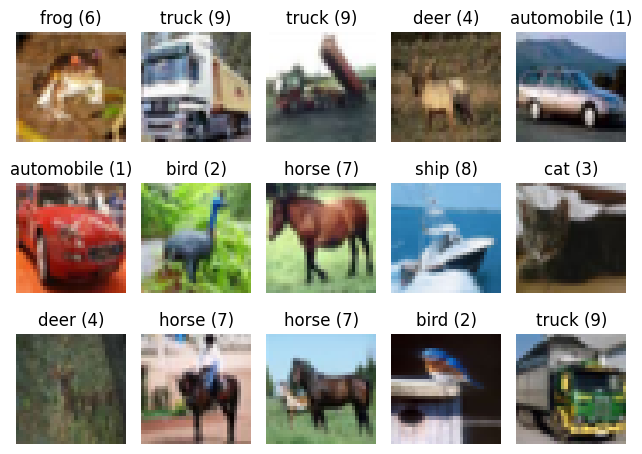

In [ ]:
# =========================
# VISUALIZAÇÃO
# =========================

fig, axes = plt.subplots(3, 5)
for i, ax in enumerate(axes.flatten()):
    # trainset.data contém as imagens em formato original (H, W, C)
    ax.imshow(trainset.data[i])
    # trainset.targets contém os índices das classes
    class_idx = trainset.targets[i]
    class_name = trainset.classes[class_idx]
    ax.set_title(f"{class_name} ({class_idx})")
    ax.axis('off')

plt.tight_layout()
plt.show()


In [ ]:
# ==============================================================================
# PRÉ-PROCESSAMENTO (FLATTEN E SUBSAMPLE)
# ==============================================================================
# Flatten: 32x32x3 -> 3072
X_train = trainset.data.reshape(50000, 3072).astype('float32') / 255.0
y_train = np.array(trainset.targets)

X_test = testset.data.reshape(10000, 3072).astype('float32') / 255.0
y_test = np.array(testset.targets)

# Subamostragem para viabilidade técnica (SVM é O(n²))
n_samples = 5000
X_train_sub = X_train[:n_samples]
y_train_sub = y_train[:n_samples]

In [ ]:
# ==============================================================================
# DEFINIÇÃO DOS PIPELINES E GRID SEARCH
# ==============================================================================
def create_grid_search(model_type='linear'):
    if model_type == 'linear':
        pipe = Pipeline([('scaler', StandardScaler()), ('pca', PCA()), ('svm', LinearSVC(max_iter=5000))])
        params = {'pca__n_components': [100, 200], 'svm__C': [0.1, 1, 10]}
    else:
        pipe = Pipeline([('scaler', StandardScaler()), ('pca', PCA()), ('svm', SVC(kernel='rbf'))])
        params = {'pca__n_components': [100, 200], 'svm__C': [1, 10], 'svm__gamma': ['scale']}

    return GridSearchCV(pipe, params, cv=3, n_jobs=-1, verbose=1)

print("\n🚀 Treinando LinearSVC...")
grid_linear = create_grid_search('linear')
grid_linear.fit(X_train_sub, y_train_sub)

print("\n🚀 Treinando SVM RBF...")
grid_rbf = create_grid_search('rbf')
grid_rbf.fit(X_train_sub, y_train_sub)


🚀 Treinando LinearSVC...
Fitting 3 folds for each of 6 candidates, totalling 18 fits

🚀 Treinando SVM RBF...
Fitting 3 folds for each of 4 candidates, totalling 12 fits


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('pca', PCA()), ('svm', SVC())]),
             n_jobs=-1,
             param_grid={'pca__n_components': [100, 200], 'svm__C': [1, 10],
                         'svm__gamma': ['scale']},
             verbose=1)

In [ ]:
# ==============================================================================
# AVALIAÇÃO E MÉTRICAS DE OVERFITTING
# ==============================================================================
best_linear = grid_linear.best_estimator_
best_rbf = grid_rbf.best_estimator_

# Acurácias
acc_train_lin = accuracy_score(y_train_sub, best_linear.predict(X_train_sub))
acc_test_lin = accuracy_score(y_test, best_linear.predict(X_test))

acc_train_rbf = accuracy_score(y_train_sub, best_rbf.predict(X_train_sub))
acc_test_rbf = accuracy_score(y_test, best_rbf.predict(X_test))

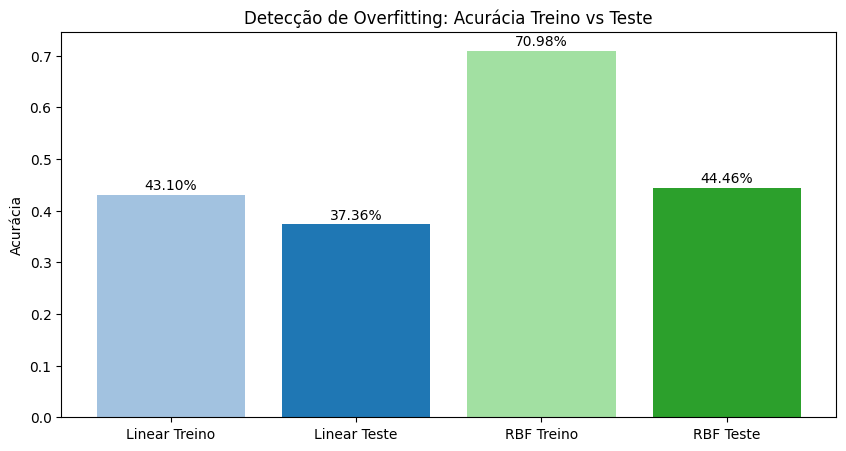

<Figure size 1000x800 with 0 Axes>

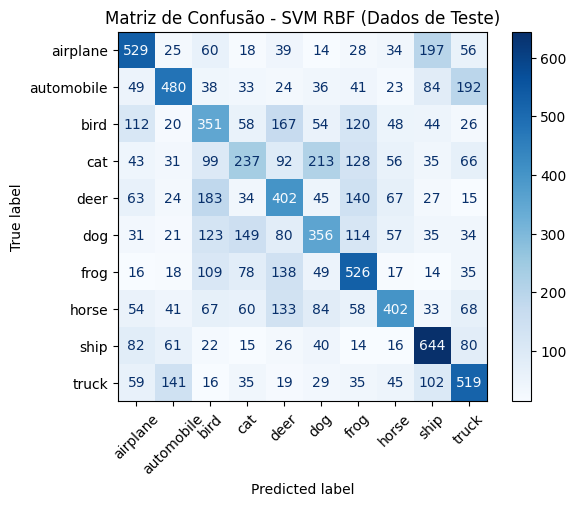


       RESUMO FINAL
LINEAR -> Treino: 43.10% | Teste: 37.36%
RBF    -> Treino: 70.98% | Teste: 44.46%
Vetores de Suporte (RBF): 4812


In [ ]:
# ==============================================================================
# VISUALIZAÇÃO DE RESULTADOS E OVERFITTING
# ==============================================================================

# Gráfico 1: Gap de Acurácia (Treino vs Teste)
labels = ['Linear Treino', 'Linear Teste', 'RBF Treino', 'RBF Teste']
accs = [acc_train_lin, acc_test_lin, acc_train_rbf, acc_test_rbf]

plt.figure(figsize=(10, 5))
plt.bar(labels, accs, color=['#A2C2E0', '#1F77B4', '#A2E0A2', '#2CA02C'])
plt.title("Detecção de Overfitting: Acurácia Treino vs Teste")
plt.ylabel("Acurácia")
for i, v in enumerate(accs):
    plt.text(i, v + 0.01, f"{v:.2%}", ha='center')
plt.show()

# Gráfico 2: Matriz de Confusão (RBF no Teste)
plt.figure(figsize=(10, 8))
ConfusionMatrixDisplay.from_estimator(best_rbf, X_test, y_test,
                                      display_labels=trainset.classes,
                                      xticks_rotation=45, cmap='Blues')
plt.title("Matriz de Confusão - SVM RBF (Dados de Teste)")
plt.show()

# Resumo Final no Console
print("\n" + "="*30)
print("       RESUMO FINAL")
print("="*30)
print(f"LINEAR -> Treino: {acc_train_lin:.2%} | Teste: {acc_test_lin:.2%}")
print(f"RBF    -> Treino: {acc_train_rbf:.2%} | Teste: {acc_test_rbf:.2%}")
print(f"Vetores de Suporte (RBF): {len(best_rbf.named_steps['svm'].support_)}")
print("="*30)

a) Qual a principal limitação estrutural da SVM para imagens?

A principal limitação é a perda da correlação espacial devido ao processo de Flattening (vetorização).Para a SVM, uma imagem $32 \times 32 \times 3$ vira apenas uma lista de $3.072$ números isolados. O modelo perde a noção de que um pixel está acima, abaixo ou ao lado de outro. Como a SVM não entende "formas" (bordas, texturas ou objetos), ela acaba classificando as imagens baseada em estatísticas globais de cores.

b) O kernel RBF compensa a ausência de estrutura espacial? Por quê?

Não. O kernel RBF compensa a não-linearidade, mas não a falta de estrutura espacial.

- O que ele faz: Ele permite que o modelo crie fronteiras de decisão curvas e complexas no espaço matemático (por isso a acurácia de treino subiu para ~71%). Ele entende que a relação entre as cores para definir um "gato" não é uma linha reta simples.

- Por que não resolve a estrutura: Ele ainda trata cada dimensão do vetor como independente. O RBF não possui invariância à translação. Se você deslocar um objeto 2 pixels para o lado na imagem, o vetor resultante será totalmente diferente para o kernel RBF, enquanto uma rede neural (CNN) ainda reconheceria o objeto na mesma posição.

Conclusão: O RBF apenas aumentou a capacidade do modelo de decorar o dataset de treino (causando o overfitting de 26% de gap), mas não deu a ele a "visão" necessária para entender a geometria das imagens.


## PARTE 2 (MLP)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 14s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



--- Resumo do Modelo ---


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,707,274 (6.51 MB)

 Trainable params: 1,707,274 (6.51 MB)

 Non-trainable params: 0 (0.00 B)


--- Iniciando Treinamento ---
Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.3320 - loss: 1.8610 - val_accuracy: 0.3929 - val_loss: 1.6953
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.4023 - loss: 1.6748 - val_accuracy: 0.4281 - val_loss: 1.5969
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4386 - loss: 1.5803 - val_accuracy: 0.4283 - val_loss: 1.6080
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.4545 - loss: 1.5312 - val_accuracy: 0.4677 - val_loss: 1.5136
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4703 - loss: 1.4847 - val_accuracy: 0.4574 - val_loss: 1.5462
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4849 - loss: 1.4496 - val_accuracy: 0.4782 - val_loss: 1.4697
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.4906 - loss: 1.4218 - val_accuracy: 0.4817 - val_loss: 1.4670
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.4994 - 

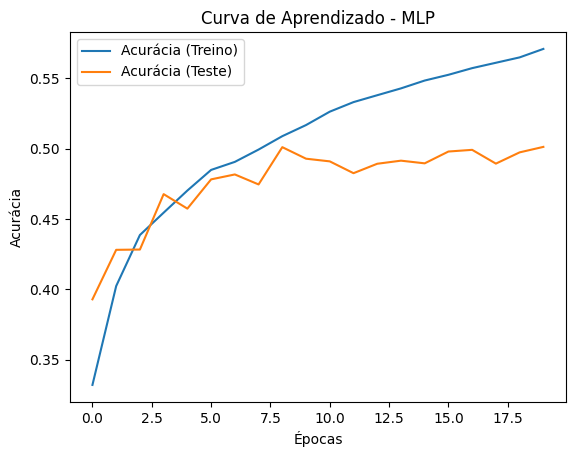

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import time

# 1. Carregar e pré-processar o dataset CIFAR-10
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Normalizar os pixels para o intervalo [0, 1]
x_train, x_test = x_train / 255.0, x_test / 255.0

# 2. Implementar a arquitetura MLP
model = models.Sequential([
    layers.Flatten(input_shape=(32, 32, 3)), # Transforma 32x32x3 em um vetor de 3072 posições
    layers.Dense(512, activation='relu'),    # Primeira camada oculta
    layers.Dense(256, activation='relu'),    # Segunda camada oculta
    layers.Dense(10, activation='softmax')   # Camada de saída (10 classes)
])

# Compilar o modelo
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 3. Reportar Métricas

# Número de parâmetros
print("\n--- Resumo do Modelo ---")
model.summary()

# Treinamento e medição de tempo
print("\n--- Iniciando Treinamento ---")
start_time = time.time()
history = model.fit(x_train, y_train, epochs=20,
                    validation_data=(x_test, y_test), batch_size=64)
end_time = time.time()

# Resultados
tempo_treino = end_time - start_time
train_acc = history.history['accuracy'][-1]
test_acc = history.history['val_accuracy'][-1]

print(f"\n--- Resultados Finais ---")
print(f"Tempo de Treinamento: {tempo_treino:.2f} segundos")
print(f"Acurácia de Treino: {train_acc:.4f}")
print(f"Acurácia de Teste: {test_acc:.4f}")

# Gráfico para observar indícios de Overfitting
plt.plot(history.history['accuracy'], label='Acurácia (Treino)')
plt.plot(history.history['val_accuracy'], label='Acurácia (Teste)')
plt.title('Curva de Aprendizado - MLP')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.legend()
plt.show()

a) Compare o número de parâmetros do MLP com o da SVM linear.

O MLP possui um número exponencialmente maior de parâmetros do que uma SVM Linear.SVM Linear: Para classificar o CIFAR-10, o SVM precisa aprender um peso para cada pixel por classe, além de um viés por classe. Como a imagem achatada tem $32 \times 32 \times 3 = 3072$ características, e existem $10$ classes, o número total de parâmetros é $(3072 \times 10) + 10 \text{ (vieses)} = \mathbf{30.730}$ parâmetros.MLP (do exemplo acima): Só a conexão da camada de entrada ($3072$ neurônios) para a primeira camada oculta ($512$ neurônios) exige $(3072 \times 512) + 512 = \mathbf{1.573.376}$ parâmetros. Somando as demais camadas, o modelo passará facilmente de 1,6 milhão de parâmetros.Conclusão: O MLP é muito mais pesado e suscetível ao overfitting porque cada neurônio da camada oculta está densamente conectado (fully connected) a todos os pixels da imagem.

b) Por que o MLP ainda não explora adequadamente a estrutura da imagem?

O MLP sofre de duas grandes limitações ao lidar com imagens:

Destruição da Topologia Espacial (O problema do Flatten): Ao achatar a imagem (transformar uma matriz 2D/3D em um vetor 1D), o MLP perde a informação de quais pixels são vizinhos. Em uma imagem, a relação entre um pixel e os que estão logo acima, abaixo ou ao lado dele é fundamental para formar bordas, texturas e formas. Para o MLP, o pixel da coordenada $(0,0)$ e o pixel da coordenada $(31,31)$ são apenas duas variáveis independentes em um longo vetor.

Falta de Invariância Espacial (Translação): Se você treinar o MLP para reconhecer um cachorro no centro da imagem e, no teste, o cachorro aparecer no canto superior direito, o modelo falhará. Isso ocorre porque o MLP não compartilha pesos; os neurônios que aprenderam o padrão do cachorro no centro são diferentes dos neurônios que processam as bordas da imagem.

## Parte 3 (CNN)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import time

# =====================================================================
# 0. CONFIGURAÇÃO E CARREGAMENTO DO DATASET
# =====================================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
epochs = 10
learning_rate = 0.001
batch_size = 64

print(f"Usando dispositivo: {device}")

# Transformações básicas para converter as imagens em tensores
transform = transforms.Compose([transforms.ToTensor()])

# Download e carregamento do CIFAR-10
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

# Criação dos DataLoaders independentes
trainloader = DataLoader(trainset, batch_size=batch_size, shuffle=True)
testloader = DataLoader(testset, batch_size=batch_size, shuffle=False)


# =====================================================================
# 1. DEFINIÇÃO DA ARQUITETURA CNN
# =====================================================================
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        # Camada Convolucional 1: entrada 3 canais (RGB), saída 16 canais, kernel 3x3
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2) # Reduz a imagem de 32x32 para 16x16

        # Camada Convolucional 2: entrada 16 canais, saída 32 canais, kernel 3x3
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2) # Reduz de 16x16 para 8x8

        # Camadas Totalmente Conectadas (Final)
        self.flatten = nn.Flatten()
        # Após 2 pools, a imagem 32x32 vira 8x8. Temos 32 canais * 8 * 8 = 2048 características
        self.fc1 = nn.Linear(32 * 8 * 8, 128)
        self.relu3 = nn.ReLU()
        self.fc2 = nn.Linear(128, 10) # 10 classes de saída

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = self.flatten(x)
        x = self.relu3(self.fc1(x))
        x = self.fc2(x)
        return x

model_cnn = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_cnn.parameters(), lr=learning_rate)


# =====================================================================
# 2. CONTAGEM DE PARÂMETROS
# =====================================================================
total_params_cnn = sum(p.numel() for p in model_cnn.parameters())
print(f"\nNúmero total de parâmetros (CNN): {total_params_cnn:,}")


# =====================================================================
# 3. LOOP DE TREINAMENTO
# =====================================================================
print("\nIniciando treinamento da CNN...")
start_time = time.time()

for epoch in range(epochs):
    model_cnn.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model_cnn(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_acc = 100 * correct / total
    print(f"Época [{epoch+1}/{epochs}] - Loss: {running_loss/len(trainloader):.4f} - Acc Treino: {train_acc:.2f}%")

total_time = time.time() - start_time
print(f"\nTempo total de treinamento: {total_time:.2f} segundos")


# =====================================================================
# 4. AVALIAÇÃO NO TESTE
# =====================================================================
model_cnn.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)
        outputs = model_cnn(images)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

test_acc = 100 * correct / total
print(f"Acurácia no Teste: {test_acc:.2f}%")

Usando dispositivo: cuda


100%|██████████| 170M/170M [00:15<00:00, 11.2MB/s]



Número total de parâmetros (CNN): 268,650

Iniciando treinamento da CNN...
Época [1/10] - Loss: 1.5654 - Acc Treino: 43.16%
Época [2/10] - Loss: 1.2471 - Acc Treino: 55.76%
Época [3/10] - Loss: 1.0997 - Acc Treino: 61.05%
Época [4/10] - Loss: 0.9992 - Acc Treino: 64.74%
Época [5/10] - Loss: 0.9238 - Acc Treino: 67.47%
Época [6/10] - Loss: 0.8640 - Acc Treino: 69.67%
Época [7/10] - Loss: 0.8126 - Acc Treino: 71.25%
Época [8/10] - Loss: 0.7571 - Acc Treino: 73.27%
Época [9/10] - Loss: 0.7150 - Acc Treino: 74.83%
Época [10/10] - Loss: 0.6761 - Acc Treino: 76.11%

Tempo total de treinamento: 102.42 segundos
Acurácia no Teste: 69.05%


a) Por que a CNN possui menos parâmetros que o MLP para desempenho superior?

O MLP possui muitos parâmetros porque conecta cada pixel de entrada a cada neurônio da camada oculta (conexão densa). A CNN, por outro lado, utiliza filtros locais (kernels) pequenos, como matrizes 3x3. Em vez de aprender um peso exclusivo para a relação entre o neurônio $X$ e o pixel $Y$, a CNN aprende os pesos desse filtro 3x3 e o desliza por toda a imagem.Isso reduz drasticamente a quantidade de parâmetros, enquanto melhora o desempenho porque a CNN foca em aprender "padrões espaciais" (bordas, texturas, formas) independentemente de onde estejam na imagem, respeitando a vizinhança entre os pixels.

b) Explique o papel do compartilhamento de pesos (weight sharing).

O compartilhamento de pesos é a mecânica principal das camadas convolucionais. Significa que os mesmos pesos (os valores numéricos de um filtro/kernel) são aplicados a todas as regiões da imagem. O papel prático disso é criar invariância à translação. Se um filtro aprende a detectar um "focinho de cachorro", e os mesmos pesos são deslizados por toda a matriz da imagem, a CNN conseguirá detectar o focinho quer ele esteja no centro, no canto superior esquerdo ou na borda direita. No MLP, como não há compartilhamento, padrões aprendidos no centro da imagem são inúteis se o objeto aparecer no canto.

c) O que aconteceria se aumentássemos a resolução da imagem para 128×128?

Duas coisas principais aconteceriam, com impactos diferentes na estrutura da rede:

Nas camadas convolucionais: O número de parâmetros não mudaria. Um filtro de tamanho 3x3 continuará tendo 9 pesos por canal de entrada, não importa se ele vai deslizar sobre uma imagem 32x32 ou 128x128. No entanto, o tempo de treinamento (custo computacional / FLOPs) aumentaria significativamente, pois o filtro teria que realizar muito mais operações matemáticas para cobrir a área maior.

Na camada totalmente conectada (Final): O número de parâmetros explodiria. Como a imagem de entrada é muito maior, a matriz que chega na camada Flatten no final das convoluções será gigantesca. A primeira camada Linear (densa) após o flatten receberá milhares de conexões a mais, aumentando severamente o peso do modelo em disco e o risco de overfitting.

## Parte 4 (CNN)

● O que vocês fizeram para melhorar a acurácia?

- Cross-validation;
- Data Augmentation;
- +1 camada convolucional (totalizando 3);
- Batch Normalization;
- Early stopping;
- Mais épocas (por conta do early stopping).

● O que tentaram e não funcionou?

Tentamos cross-validation sem early stopping, mas a acurácia de teste subiu apenas 5 pontos percentuais.

● Qual foi a principal limitação encontrada?

● Se tivessem mais tempo, o que fariam diferente?

- Adicionar mais camadas de convolução;
- Testar a AlexNet.


Usando dispositivo: cuda

Número total de parâmetros: 2,193,674

Iniciando treinamento...

Época [1/20] | Loss: 1.8956 | Acc Treino: 28.21% | Acc Validação: 38.86%
Época [2/20] | Loss: 1.6584 | Acc Treino: 36.49% | Acc Validação: 48.92%
Época [3/20] | Loss: 1.5440 | Acc Treino: 41.15% | Acc Validação: 55.20%
Época [4/20] | Loss: 1.4847 | Acc Treino: 43.84% | Acc Validação: 55.47%
Época [5/20] | Loss: 1.4316 | Acc Treino: 45.75% | Acc Validação: 60.34%
Época [6/20] | Loss: 1.3987 | Acc Treino: 47.17% | Acc Validação: 62.50%
Época [7/20] | Loss: 1.3686 | Acc Treino: 48.57% | Acc Validação: 62.28%
Época [8/20] | Loss: 1.3450 | Acc Treino: 49.18% | Acc Validação: 63.31%
Época [9/20] | Loss: 1.3113 | Acc Treino: 50.57% | Acc Validação: 61.97%
Época [10/20] | Loss: 1.2902 | Acc Treino: 51.42% | Acc Validação: 64.58%
Época [11/20] | Loss: 1.2696 | Acc Treino: 52.66% | Acc Validação: 64.92%
Época [12/20] | Loss: 1.2507 | Acc Treino: 53.20% | Acc Validação: 68.27%
Época [13/20] | Loss: 1.2309 |

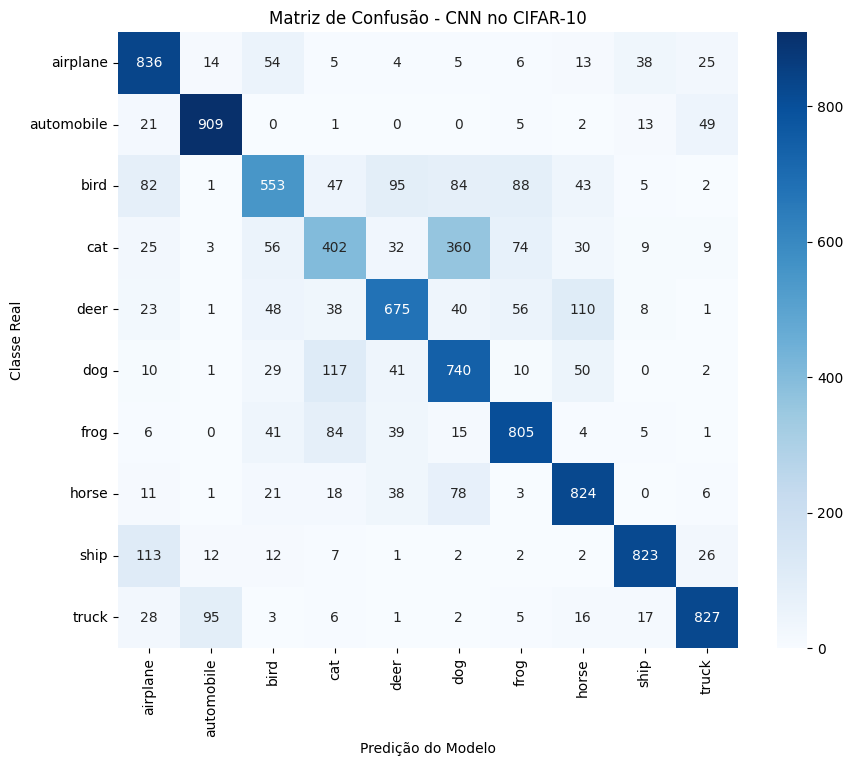

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torchvision
import torchvision.transforms as transforms
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# =====================================================================
# 0. CONFIGURAÇÃO E CARREGAMENTO DO DATASET
# =====================================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
epochs = 20 # Aumentamos para 20 para dar tempo da rede aprender
learning_rate = 0.001
batch_size = 64

print(f"Usando dispositivo: {device}")

# Data Augmentation para o Treino (Evita Overfitting)
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)) # Normalização padrão do CIFAR-10
])

# Apenas transformação e normalização para Validação e Teste
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

# Carrega o dataset de treino completo (50.000 imagens)
full_trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)

# Divisão: 40.000 para Treino e 10.000 para Validação
train_size = int(0.8 * len(full_trainset))
val_size = len(full_trainset) - train_size
train_dataset, val_dataset = random_split(full_trainset, [train_size, val_size])

# Dataset de Teste (10.000 imagens independentes)
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)

classes = full_trainset.classes

# DataLoaders
trainloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
testloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# =====================================================================
# 1. DEFINIÇÃO DA ARQUITETURA CNN (V2)
# =====================================================================
class ImprovedCNN(nn.Module):
    def __init__(self):
        super(ImprovedCNN, self).__init__()

        # Bloco 1
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        # Bloco 2
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool1 = nn.MaxPool2d(2, 2) # Reduz para 16x16

        # Bloco 3
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool2 = nn.MaxPool2d(2, 2) # Reduz para 8x8

        self.relu = nn.ReLU()

        # Classificador Final
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(128 * 8 * 8, 256)
        self.dropout = nn.Dropout(0.5) # Desliga 50% dos neurônios
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.pool1(self.relu(self.bn2(self.conv2(x))))
        x = self.pool2(self.relu(self.bn3(self.conv3(x))))
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

model = ImprovedCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# =====================================================================
# 2. LOOP DE TREINAMENTO COM VALIDAÇÃO
# =====================================================================
print(f"\nNúmero total de parâmetros: {sum(p.numel() for p in model.parameters()):,}")
print("\nIniciando treinamento...\n")
start_time = time.time()

for epoch in range(epochs):
    # Fase de Treino
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_acc = 100 * correct / total

    # Fase de Validação
    model.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for images, labels in valloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

    val_acc = 100 * val_correct / val_total

    print(f"Época [{epoch+1}/{epochs}] | Loss: {running_loss/len(trainloader):.4f} | Acc Treino: {train_acc:.2f}% | Acc Validação: {val_acc:.2f}%")

print(f"\nTempo total: {time.time() - start_time:.2f} segundos")

# =====================================================================
# 3. AVALIAÇÃO FINAL NO TESTE E MATRIZ DE CONFUSÃO
# =====================================================================
model.eval()
test_correct, test_total = 0, 0
all_preds = []
all_targets = []

with torch.no_grad():
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)

        test_total += labels.size(0)
        test_correct += predicted.eq(labels).sum().item()

        # Guarda as predições para a matriz de confusão
        all_preds.extend(predicted.cpu().numpy())
        all_targets.extend(labels.cpu().numpy())

test_acc = 100 * test_correct / test_total
print(f"\n--- Acurácia Final no Teste (Dados Inéditos): {test_acc:.2f}% ---")

# =====================================================================
# 4. PLOTAR A MATRIZ DE CONFUSÃO
# =====================================================================
cm = confusion_matrix(all_targets, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predição do Modelo')
plt.ylabel('Classe Real')
plt.title('Matriz de Confusão - CNN no CIFAR-10')
plt.show()

Usando dispositivo: cuda

Número total de parâmetros: 2,193,674

Iniciando treinamento...

Época [01/50] | Loss Treino: 1.8974 - Acc: 27.43% | Loss Val: 1.5707 - Acc: 40.58%
Época [02/50] | Loss Treino: 1.6655 - Acc: 35.60% | Loss Val: 1.4200 - Acc: 48.59%
Época [03/50] | Loss Treino: 1.5561 - Acc: 40.70% | Loss Val: 1.3766 - Acc: 49.18%
Época [04/50] | Loss Treino: 1.5034 - Acc: 43.11% | Loss Val: 1.2836 - Acc: 53.70%
Época [05/50] | Loss Treino: 1.4610 - Acc: 45.48% | Loss Val: 1.2159 - Acc: 55.89%
Época [06/50] | Loss Treino: 1.4121 - Acc: 47.38% | Loss Val: 1.1742 - Acc: 57.99%
Época [07/50] | Loss Treino: 1.3851 - Acc: 48.54% | Loss Val: 1.2307 - Acc: 56.12%
   -> Sem melhoria na validação. Paciência: 1/5
Época [08/50] | Loss Treino: 1.3623 - Acc: 49.90% | Loss Val: 1.1453 - Acc: 60.67%
Época [09/50] | Loss Treino: 1.3245 - Acc: 51.06% | Loss Val: 1.0638 - Acc: 63.37%
Época [10/50] | Loss Treino: 1.3055 - Acc: 51.57% | Loss Val: 1.0600 - Acc: 61.95%
Época [11/50] | Loss Treino: 1.

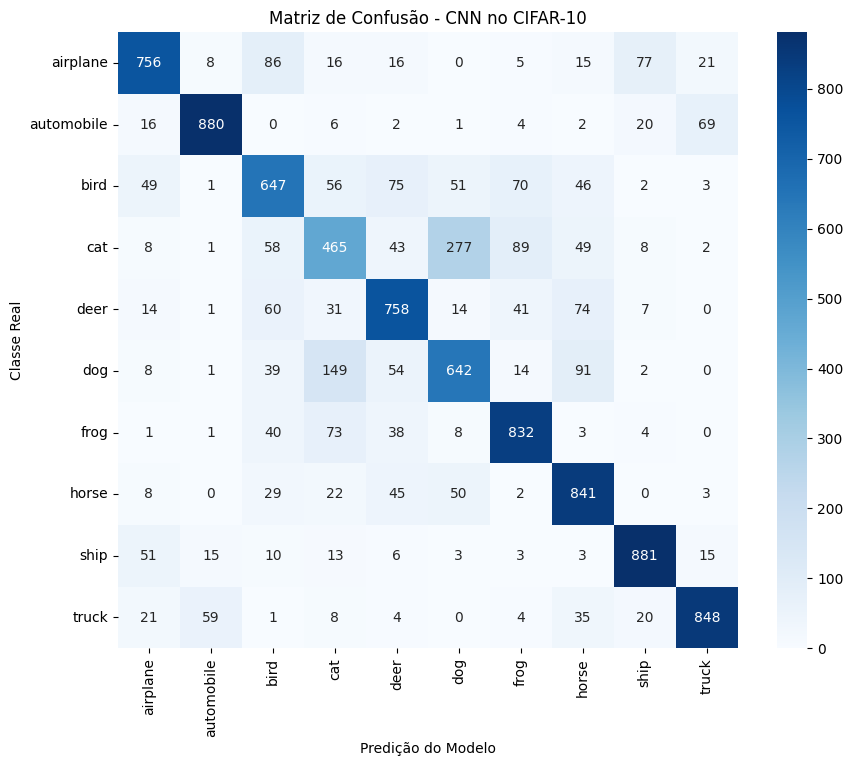

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torchvision
import torchvision.transforms as transforms
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import copy # Necessário para salvar os melhores pesos da rede

# =====================================================================
# 0. CONFIGURAÇÃO E CARREGAMENTO DO DATASET
# =====================================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
epochs = 50 # Podemos colocar um número alto agora, pois o Early Stopping vai parar antes
learning_rate = 0.001
batch_size = 64
patience = 5 # Quantas épocas esperar sem melhoria na validação antes de parar

print(f"Usando dispositivo: {device}")

# Data Augmentation para o Treino
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

# Transformação para Validação e Teste (Sem Augmentation)
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

# Carrega e divide o dataset
full_trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
train_size = int(0.8 * len(full_trainset))
val_size = len(full_trainset) - train_size
train_dataset, val_dataset = random_split(full_trainset, [train_size, val_size])

test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)
classes = full_trainset.classes

# DataLoaders
trainloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
testloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# =====================================================================
# 1. DEFINIÇÃO DA ARQUITETURA CNN (V2)
# =====================================================================
class ImprovedCNN(nn.Module):
    def __init__(self):
        super(ImprovedCNN, self).__init__()

        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool1 = nn.MaxPool2d(2, 2)

        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool2 = nn.MaxPool2d(2, 2)

        self.relu = nn.ReLU()

        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(128 * 8 * 8, 256)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.pool1(self.relu(self.bn2(self.conv2(x))))
        x = self.pool2(self.relu(self.bn3(self.conv3(x))))
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

model = ImprovedCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# =====================================================================
# 2. LOOP DE TREINAMENTO COM EARLY STOPPING
# =====================================================================
print(f"\nNúmero total de parâmetros: {sum(p.numel() for p in model.parameters()):,}")
print("\nIniciando treinamento...\n")
start_time = time.time()

# Variáveis do Early Stopping
best_val_loss = float('inf')
patience_counter = 0
best_model_wts = copy.deepcopy(model.state_dict())

for epoch in range(epochs):
    # --- Fase de Treino ---
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_loss = running_loss / len(trainloader)
    train_acc = 100 * correct / total

    # --- Fase de Validação ---
    model.eval()
    val_running_loss, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in valloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item()
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

    val_loss = val_running_loss / len(valloader)
    val_acc = 100 * val_correct / val_total

    print(f"Época [{epoch+1:02d}/{epochs}] | Loss Treino: {train_loss:.4f} - Acc: {train_acc:.2f}% | Loss Val: {val_loss:.4f} - Acc: {val_acc:.2f}%")

    # --- Lógica do Early Stopping ---
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_model_wts = copy.deepcopy(model.state_dict()) # Salva os melhores pesos
    else:
        patience_counter += 1
        print(f"   -> Sem melhoria na validação. Paciência: {patience_counter}/{patience}")
        if patience_counter >= patience:
            print(f"\n[!] Early Stopping ativado na época {epoch+1}. Restaurando melhores pesos.")
            break

print(f"\nTempo total: {time.time() - start_time:.2f} segundos")

# Carrega os melhores pesos encontrados antes do teste final
model.load_state_dict(best_model_wts)

# =====================================================================
# 3. AVALIAÇÃO FINAL NO TESTE E MATRIZ DE CONFUSÃO
# =====================================================================
model.eval()
test_correct, test_total = 0, 0
all_preds = []
all_targets = []

with torch.no_grad():
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)

        test_total += labels.size(0)
        test_correct += predicted.eq(labels).sum().item()

        all_preds.extend(predicted.cpu().numpy())
        all_targets.extend(labels.cpu().numpy())

test_acc = 100 * test_correct / test_total
print(f"\n--- Acurácia Final no Teste (com o melhor modelo salvo): {test_acc:.2f}% ---")

# =====================================================================
# 4. PLOTAR A MATRIZ DE CONFUSÃO
# =====================================================================
cm = confusion_matrix(all_targets, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predição do Modelo')
plt.ylabel('Classe Real')
plt.title('Matriz de Confusão - CNN no CIFAR-10')
plt.show()